# Ablation Row 4 — + Hard negative mining

| | Value |
|---|---|
| Features | full (same as rows 2-3) |
| PCA | 4677 components |
| Scales | (0.75, 1.0, 1.5) + cross-scale NMS |
| HNM | **4 rounds** (loaded from cached run; converged 11508 → 581 → 753 → 809) |
| Threshold | `cfg.detection_threshold = 1.5` (default — row 5 will tune this) |

This notebook **loads** the post-HNM model from `microglia-artifacts-row4/`
(copied from the 2026-05-22 refactored pipeline run, which executed the exact
same HNM logic: full features → fit-once scaler+PCA → 4 rounds with fixed C,
colour-fix, fit-once design).

**Test evaluation only — no retraining.** Saves ~70 min vs running HNM from
scratch. If you ever need to rerun HNM, restore the original cell set from git
history.


## 1  Imports + Config

In [1]:
import os
import joblib
import numpy as np
import matplotlib.image as mpimg

from pipeline import (
    Config,
    extract_raw_features, fit_pipeline,
    tune_svm, train_svm, evaluate_classifier,
    process_image, multi_scale_detect, non_max_suppression,
    load_gt_boxes, evaluate_detections, plot_gt_vs_pred,
    save_hard_negatives, tune_detection_threshold,
    ensure_test_patches, patch_level_test_eval, detection_level_test_eval,
    extract_features, list_images,
)

%matplotlib inline

In [2]:
cfg = Config(
    artifact_dir='./microglia-artifacts-row4',
    feature_mode='full',
    scale_factors=(0.75, 1.0, 1.5),
    pca_n_components=4677,
    detection_threshold=1.5,
)
os.makedirs(cfg.artifact_dir, exist_ok=True)
os.makedirs(cfg.hnm_folder, exist_ok=True)
print(cfg)

Config(image_rois_csv='../Image_ROIs.csv', source_images='../Source_images', test_dir='../test_images', microglia_folder='./Processed_training_images/Train/Microglia', noise_folder='./Processed_training_images/Train/Noise', microglia_val_folder='./Processed_training_images/Validate/Microglia', noise_val_folder='./Processed_training_images/Validate/Noise', microglia_test_folder='./Processed_training_images/Test/Microglia', noise_test_folder='./Processed_training_images/Test/Noise', hnm_folder='./Processed_training_images/HardNegatives', artifact_dir='./microglia-artifacts-row4', features_cache='./microglia-artifacts-row4/features_cache.npz', svm_clf_path='./microglia-artifacts-row4/svm_clf.pkl', scaler_path='./microglia-artifacts-row4/scaler.pkl', pca_path='./microglia-artifacts-row4/pca.pkl', val_paths_cache='./microglia-artifacts-row4/val_paths.txt', hnm_train_final='./microglia-artifacts-row4/hnm_train_final.npz', image_size=2048, window_size=64, feature_mode='full', scale_factors=(0

## 2  Load HNM-trained model

In [3]:
# Load the post-HNM svm_clf + scaler + pca that were saved by the prior
# fit-once HNM run. cfg.artifact_dir points at the row-4 copy; row 5 will use
# this same dir for threshold tuning.
svm_clf = joblib.load(cfg.svm_clf_path)
scaler  = joblib.load(cfg.scaler_path)
pca     = joblib.load(cfg.pca_path)

print(f"Loaded HNM-trained model from {cfg.artifact_dir}/")
print(f"  svm_clf : C={svm_clf.C}, coef shape={svm_clf.coef_.shape}, n_iter={getattr(svm_clf, 'n_iter_', '?')}")
print(f"  scaler  : n_features_in_={scaler.n_features_in_}")
print(f"  pca     : n_components_={pca.n_components_}, "
      f"variance_retained={pca.explained_variance_ratio_.sum():.1%}")

Loaded HNM-trained model from ./microglia-artifacts-row4/
  svm_clf : C=10.0, coef shape=(1, 4677), n_iter=182
  scaler  : n_features_in_=32801
  pca     : n_components_=4677, variance_retained=89.8%


## 3  Held-out test evaluation (default threshold = 1.5)

── Patch-level test ──


  [test microglia] 245/245 (100%) — 245 feature vectors extracted


  [test noise] 1922/1922 (100%) — 1922 feature vectors extracted


[test] Accuracy  : 0.9192
[test] Precision : 0.9487
[test] Recall    : 0.3020
[test] F1-Score  : 0.4582

── Detection-level test (multi-scale, untuned t=1.50) ──
Running detection on 2 test images at scales (0.75, 1.0, 1.5), threshold=1.50

── 13_s46 ──
  scale=0.75 (1536×1536px)  

/home/ec2-user/lx-svm-venv/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


...

     67% 

     76% 

     86% 

     95% 

100%
  → 165 candidates at this scale
  Total candidates : 432
  After NMS        : 182
  Detection time: 244.6s
  GT=123  Pred=182  TP=34  FP=148  FN=89  P=0.187  R=0.276


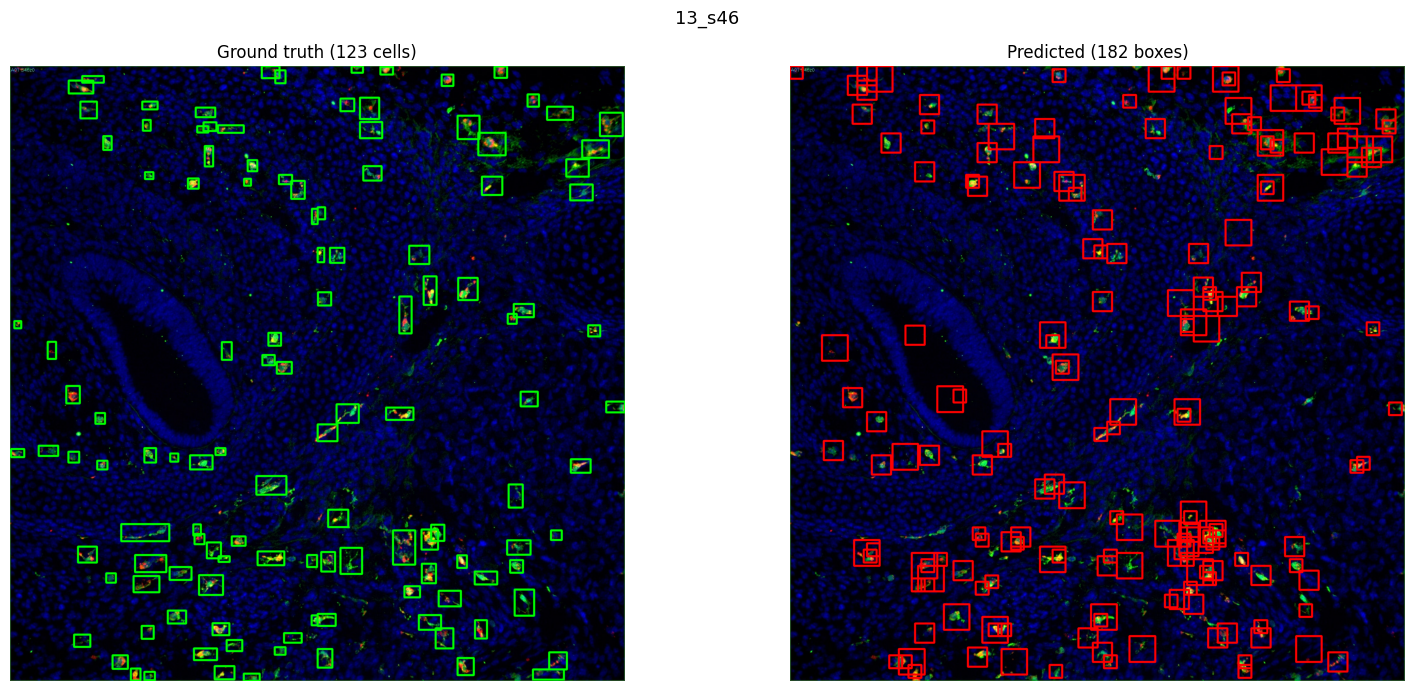


── 14_s47 ──
  scale=0.75 (1536×1536px)  

/home/ec2-user/lx-svm-venv/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


      0% 

      9% 

     19% 

...

     67% 

     76% 

     86% 

     95% 

100%
  → 205 candidates at this scale
  Total candidates : 535
  After NMS        : 219
  Detection time: 241.3s
  GT=122  Pred=219  TP=37  FP=182  FN=85  P=0.169  R=0.303


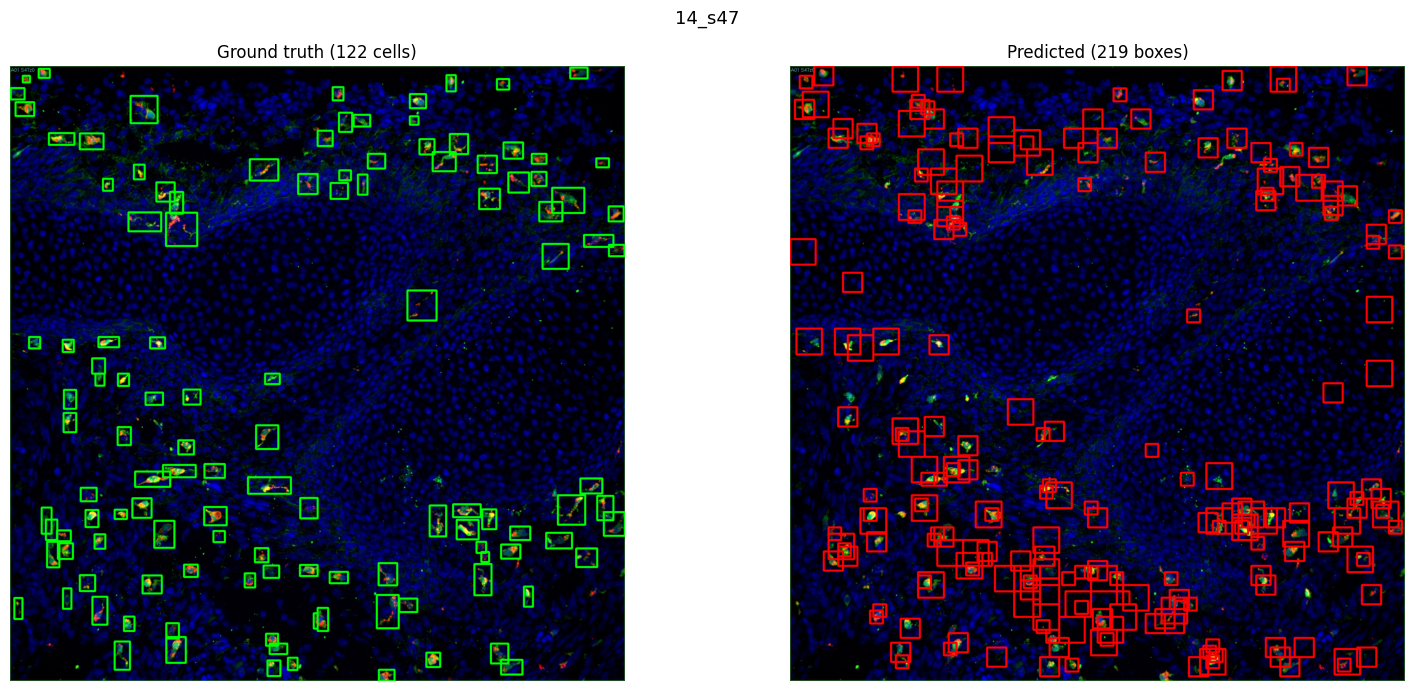


== AGGREGATE  TP=71  FP=330  FN=174
   Precision=0.177  Recall=0.290  F1=0.220


In [4]:
ensure_test_patches(cfg)

print("── Patch-level test ──")
patch_level_test_eval(svm_clf, scaler, pca, cfg)

print("\n── Detection-level test (multi-scale, untuned t=%.2f) ──" % cfg.detection_threshold)
row4_metrics = detection_level_test_eval(svm_clf, scaler, pca, cfg, show_plots=True)